In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
df = pd.read_csv("../data/student-mat.csv", sep=";")

In [ ]:
# Preview the first 5 rows
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


### DATA AUDITION

In [6]:
# Structural Audit (shape & datatype)
print(f'Dataset Shape: {df.shape}')
df.info()
df.columns

Dataset Shape: (395, 33)
<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 no

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='str')

In [8]:
# Quality Audit (missing values)
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found!")

No missing values found!


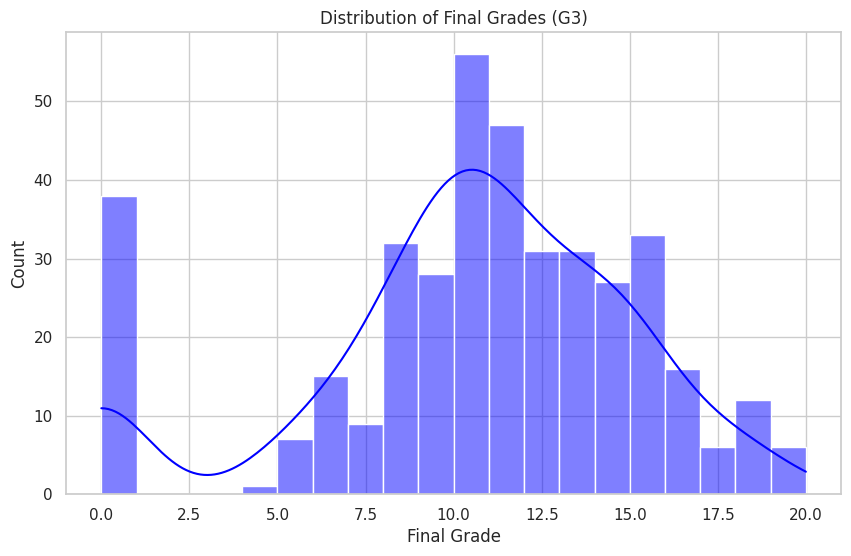

In [10]:
# Target Variable Inspection
sns.histplot(df['G3'], kde=True, bins=20, color='blue')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Final Grade')
plt.ylabel('Count')
plt.show()

In [11]:
# Correlation Analysis (Feature Selection)
numerical_df = df.select_dtypes(include=[np.number])
correlation_matrix = numerical_df.corr()

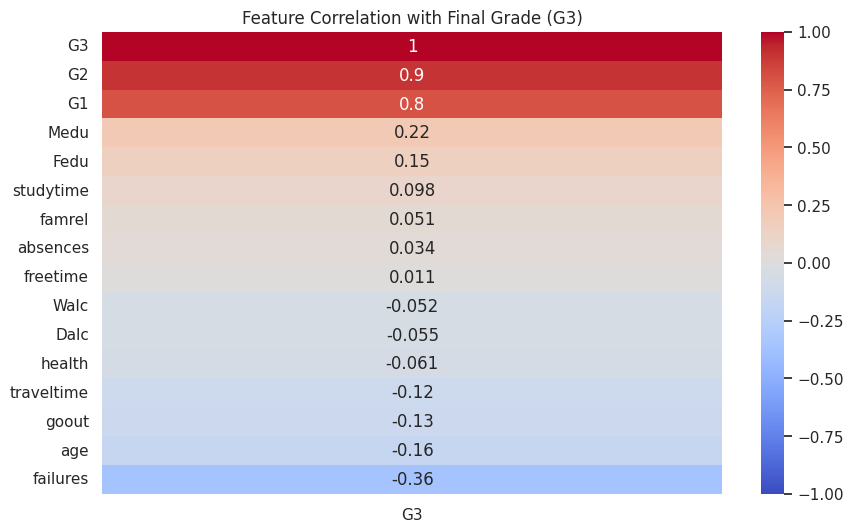

In [12]:
# Plot the heatmap focusing on how variables correlate with G3
sns.heatmap(correlation_matrix[['G3']].sort_values(by='G3', ascending=False), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation with Final Grade (G3)')
plt.show()

# Exploratory Data Analysis (EDA) Summary & Insights

## 📊 Target Variable Analysis (`G3`)
* **Distribution:** The final grade `G3` follows a mostly normal distribution centered around a score of 10–11.
* **The Zero-Grade Spike Anomaly:** There is a highly distinct, unnatural spike of nearly 40 students who scored an absolute **0**. Because the distribution cuts off cleanly around a grade of 5, a score of 0 strongly indicates non-numerical outliers (e.g., students who dropped the class, missed the final exam, or had unrecorded grades) rather than true academic capability.
* **ML Strategy:** Keeping these 0s will heavily skew linear regression metrics. We will experiment with two training pipelines: one with the 0s retained and one with them isolated/removed.

## 🧮 Feature Correlation Breakdown
The Pearson correlation analysis with `G3` highlights which variables hold the strongest predictive signal:

### 1. Academic History (Strongest Indicators)
* **`G2` (0.90) & `G1` (0.80):** Show an overwhelming positive linear relationship with the final grade. 
* **ML Strategy:** While highly predictive, including them can mask the impact of behavioral features. We should build variations of our model that exclude `G1`/`G2` to simulate "early warning" predictions before midterms happen.

### 2. Negative Performance Blockers
* **`failures` (-0.36):** The strongest non-grade feature. A history of past class failures heavily correlates with lower final performance.
* **`age` (-0.16) & `goout` (-0.13):** Higher age (potentially indicating being held back) and high frequency of socializing with friends act as negative weights.

### 3. Modest Positive Drivers
* **`Medu` (0.22) & `Fedu` (0.15):** Parental education levels show a mild positive correlation, indicating household academic background plays a supportive role.
* **`studytime` (0.098):** Shows a minor, though positive, relationship with higher grades.

## 🛠️ Upcoming Feature Engineering Checklist
1. Handle the target variable zero-spike anomaly.
2. Address multicollinearity between `G1` and `G2` (consider regularization methods like Ridge/Lasso).
3. Encode non-numerical categorical columns (e.g., `school`, `sex`, `address`) into numerical values.